# Session 9 — Output Analysis for Steady-State Simulations

**Course:** Decision Modelling — Simulation Part
**Session:** 9 of 12 (simulation portion)

## Learning objectives

By the end of this session you should be able to:

- Design an experiment for a steady-state (non-terminating) simulation
- Detect and remove warm-up bias from simulation output
- Compute steady-state confidence intervals using batching

## Format note: flipped classroom

- **Pre-class (screencast + this notebook's Part A):** build a new SimPy model — a single machine subject to random breakdowns and repairs, using SimPy's **process interrupt** mechanism. Watch the screencast and run Part A yourself before class.
- **In-class (Part B):** the statistical core — why Session 8's "just run many independent replications" trick doesn't transfer here, and what to do instead: warm-up detection and batch means.

## Where this session fits

- **Looking back:** Session 8 handled *terminating* systems (a natural closing time), where independent replications were the natural unit of analysis. Today's system has **no natural ending** — it's meant to represent long-run, ongoing behavior (think: a machine that runs indefinitely, not a shop that closes each evening).
- **New SimPy feature today:** `Process.interrupt()` — modeling a machine that can be interrupted mid-task by a breakdown, repaired, and then resumes where it left off.
- **Looking ahead:** Session 10 revisits comparison methods (CRN, ANOVA) — now for steady-state systems — and Session 11 combines everything so far into a full production/inventory capstone model.


## Further reading (supplementary, not required)

- A chapter or paper on warm-up detection (e.g. Welch's graphical method) and batch-means analysis for steady-state simulation output — check the course reading list for the current reference.


---
# Part A (pre-class): a machine subject to breakdowns

Watch the accompanying screencast for a walkthrough of the code below, then run it yourself before class.

## A new SimPy mechanic: interrupting a process

Until now, a process only ever paused on a `yield` and resumed when that specific event completed. **`Process.interrupt()`** lets one process forcibly interrupt *another* running process — exactly what a machine breakdown does to whatever job is currently being processed.

The pattern: the machine process tracks **remaining processing time** for the job it's currently working on. If interrupted, it records how much time has elapsed, waits out a repair delay, and then resumes processing the **remaining** time — the job isn't lost or restarted, just paused.


In [1]:
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

class Job:
    def __init__(self, job_id, arrival_time, service_time):
        self.job_id = job_id
        self.arrival_time = arrival_time
        self.service_time = service_time

class MachineState:
    def __init__(self):
        self.broken = False
        self.processing = False
        self.parts_completed = 0

def job_generator(env, mean_interarrival, mean_service, job_store, rng):
    job_id = 0
    while True:
        yield env.timeout(rng.exponential(mean_interarrival))
        job_id += 1
        job = Job(job_id, env.now, rng.exponential(mean_service))
        yield job_store.put(job)

def machine(env, job_store, state, repair_time_mean, rng, records):
    while True:
        job = yield job_store.get()
        wait_time = env.now - job.arrival_time
        remaining = job.service_time
        state.processing = True

        while remaining > 1e-9:
            start = env.now
            try:
                yield env.timeout(remaining)
                remaining = 0
            except simpy.Interrupt:
                elapsed = env.now - start
                remaining -= elapsed
                state.broken = True
                yield env.timeout(rng.exponential(repair_time_mean))
                state.broken = False

        state.processing = False
        departure_time = env.now
        state.parts_completed += 1
        records.append({
            'job_id': job.job_id, 'arrival_time': job.arrival_time,
            'wait_time': wait_time, 'departure_time': departure_time,
            'time_in_system': departure_time - job.arrival_time,
        })

def breakdown_generator(env, machine_process, state, mttf_mean, rng):
    while True:
        yield env.timeout(rng.exponential(mttf_mean))
        if state.processing and not state.broken:
            machine_process.interrupt()

def monitor(env, job_store, state, sample_interval, samples):
    while True:
        samples.append((env.now, len(job_store.items) + (0 if state.broken else 0) +
                         (1 if (state.parts_completed >= 0 and False) else 0)))
        # (queue length only; see note below on why we track this separately)
        yield env.timeout(sample_interval)


**A note on the monitor above:** measuring "number in system" correctly when a job can be *mid-service, but paused for repair* takes a little more bookkeeping than Session 6's simple case. To keep Part A focused on the interrupt mechanic itself, we'll use a cleaner monitoring approach in Part B (tracking active job count directly) rather than inferring it from queue contents. For now, let's just confirm the breakdown mechanic works as intended.


In [2]:
mean_interarrival = 6.0
mean_service = 4.0
mttf_mean = 60.0        # mean time to failure: machine breaks down roughly every 60 minutes, on average
repair_time_mean = 15.0 # mean repair time

rng = np.random.default_rng(seed=1)
env = simpy.Environment()
job_store = simpy.Store(env)
state = MachineState()
records = []

env.process(job_generator(env, mean_interarrival, mean_service, job_store, rng))
machine_process = env.process(machine(env, job_store, state, repair_time_mean, rng, records))
env.process(breakdown_generator(env, machine_process, state, mttf_mean, rng))

env.run(until=2000)

df_a = pd.DataFrame(records)
print(f"Jobs completed: {len(df_a)}")
print(f"Mean wait time: {df_a['wait_time'].mean():.2f} minutes")
print(f"Mean time in system: {df_a['time_in_system'].mean():.2f} minutes")


Jobs completed: 304
Mean wait time: 19.73 minutes
Mean time in system: 24.66 minutes


The breakdown mechanic is working: jobs still complete, but wait times will be noticeably higher than an equivalent breakdown-free system, since repairs periodically steal capacity away. Part A is done here — the rest of this notebook (Part B) is for class.


---
# Part B (in-class): warm-up detection and batch means

## 1. Why the replication trick from Session 8 doesn't transfer directly

Session 8's terminating system had a natural start (empty clinic, 9am) and end (closing time, everyone processed). Running many independent replications made sense because each one *was* a complete, comparable "day."

Today's machine has **no natural ending** — it's meant to represent indefinite, ongoing operation. If we just replayed Session 8's trick (many short independent runs, each starting empty), **every single run would be dominated by the startup transient** — the period right after the simulation starts, when the system is artificially empty and hasn't yet settled into its typical long-run behavior. We'd be systematically *underestimating* steady-state congestion. This is called **warm-up bias**, and it's the central problem of this session.


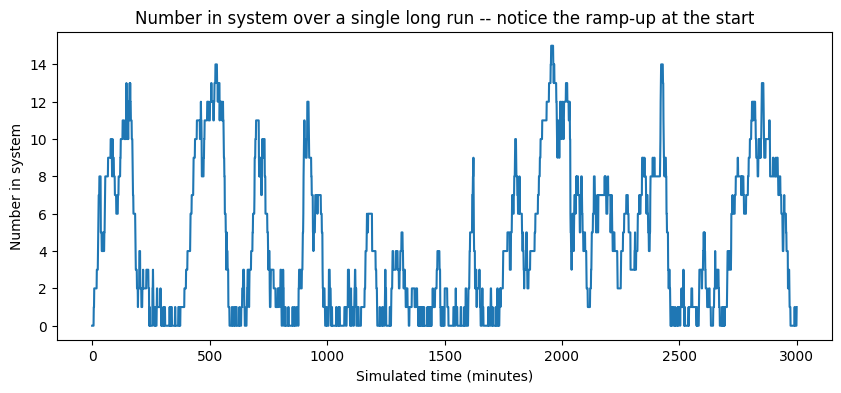

In [3]:
def run_machine_system(run_length, seed, sample_interval=1.0):
    rng = np.random.default_rng(seed)
    env = simpy.Environment()
    job_store = simpy.Store(env)
    state = MachineState()
    records = []
    n_in_system = {'count': 0}
    samples = []

    def job_generator_tracked(env, mean_interarrival, mean_service, job_store, rng, n_in_system):
        job_id = 0
        while True:
            yield env.timeout(rng.exponential(mean_interarrival))
            job_id += 1
            n_in_system['count'] += 1
            job = Job(job_id, env.now, rng.exponential(mean_service))
            yield job_store.put(job)

    def machine_tracked(env, job_store, state, repair_time_mean, rng, records, n_in_system):
        while True:
            job = yield job_store.get()
            wait_time = env.now - job.arrival_time
            remaining = job.service_time
            state.processing = True
            while remaining > 1e-9:
                start = env.now
                try:
                    yield env.timeout(remaining)
                    remaining = 0
                except simpy.Interrupt:
                    elapsed = env.now - start
                    remaining -= elapsed
                    state.broken = True
                    yield env.timeout(rng.exponential(repair_time_mean))
                    state.broken = False
            state.processing = False
            departure_time = env.now
            n_in_system['count'] -= 1
            records.append({'job_id': job.job_id, 'wait_time': wait_time,
                             'time_in_system': departure_time - job.arrival_time,
                             'departure_time': departure_time})

    def monitor_tracked(env, n_in_system, sample_interval, samples):
        while True:
            samples.append((env.now, n_in_system['count']))
            yield env.timeout(sample_interval)

    env.process(job_generator_tracked(env, mean_interarrival, mean_service, job_store, rng, n_in_system))
    machine_proc = env.process(machine_tracked(env, job_store, state, repair_time_mean, rng, records, n_in_system))
    env.process(breakdown_generator(env, machine_proc, state, mttf_mean, rng))
    env.process(monitor_tracked(env, n_in_system, sample_interval, samples))

    env.run(until=run_length)
    return pd.DataFrame(records), pd.DataFrame(samples, columns=['time', 'n_in_system'])

df_single, samples_single = run_machine_system(run_length=3000, seed=1)

plt.figure(figsize=(10, 4))
plt.plot(samples_single['time'], samples_single['n_in_system'])
plt.xlabel('Simulated time (minutes)')
plt.ylabel('Number in system')
plt.title('Number in system over a single long run -- notice the ramp-up at the start')
plt.show()


## 2. Welch's method: detecting the warm-up period visually

Welch's method: run **several independent replications**, average the number-in-system across replications *at each point in time* (this cancels out random noise but preserves the systematic warm-up trend, since every replication starts empty), then apply a **moving average** to smooth the result. The point where the smoothed curve levels off is your estimated warm-up length — discard data before that point in your actual analysis.


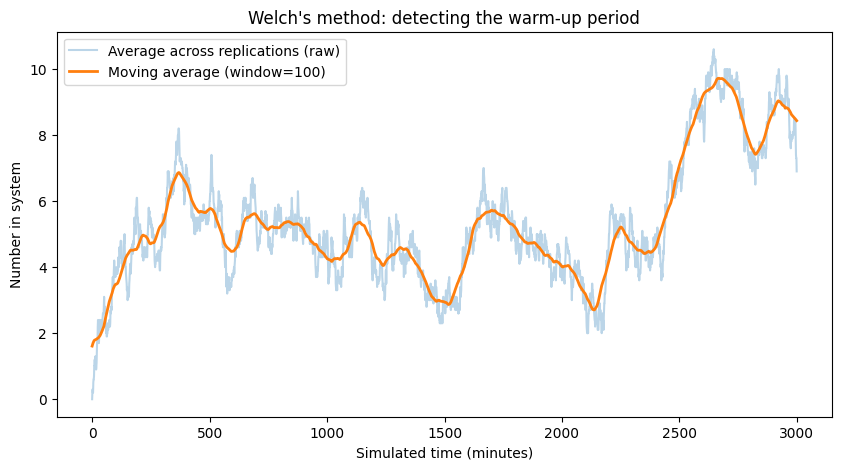

In [4]:
n_replications_welch = 10
run_length_welch = 3000
sample_interval = 1.0

all_samples = []
for i in range(n_replications_welch):
    _, samples_i = run_machine_system(run_length=run_length_welch, seed=100 + i, sample_interval=sample_interval)
    all_samples.append(samples_i.set_index('time')['n_in_system'])

welch_df = pd.concat(all_samples, axis=1)
welch_avg = welch_df.mean(axis=1)  # average across replications, at each time point

def moving_average(series, window):
    return series.rolling(window=window, center=True, min_periods=1).mean()

window = 100  # smoothing window, in time units (since sample_interval=1.0, this is also # of samples)
welch_smoothed = moving_average(welch_avg, window)

plt.figure(figsize=(10, 5))
plt.plot(welch_avg.index, welch_avg.values, alpha=0.3, label='Average across replications (raw)')
plt.plot(welch_smoothed.index, welch_smoothed.values, linewidth=2, label=f'Moving average (window={window})')
plt.xlabel('Simulated time (minutes)')
plt.ylabel('Number in system')
plt.title("Welch's method: detecting the warm-up period")
plt.legend()
plt.show()


### Reading the plot

Look for the point where the smoothed curve stops trending upward (or downward) and starts fluctuating around a roughly constant level — that's your estimated warm-up length, `l`. Pick a value for `l` from the plot above before continuing (a typical choice here is somewhere in the range of a few hundred time units, but read it from **your** plot, not this text, since it depends on the random draws).


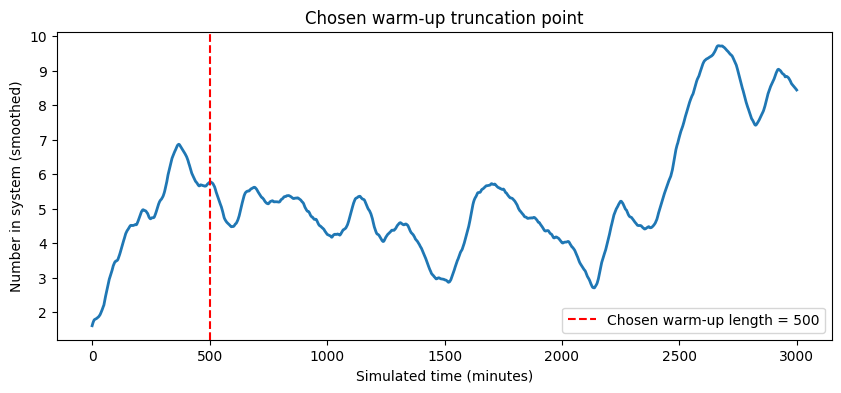

In [5]:
# Set this based on what you read from the Welch plot above
warmup_length = 500  # <-- adjust based on your own reading of the plot

plt.figure(figsize=(10, 4))
plt.plot(welch_smoothed.index, welch_smoothed.values, linewidth=2)
plt.axvline(warmup_length, color='red', linestyle='--', label=f'Chosen warm-up length = {warmup_length}')
plt.xlabel('Simulated time (minutes)')
plt.ylabel('Number in system (smoothed)')
plt.legend()
plt.title('Chosen warm-up truncation point')
plt.show()


## 3. Batch means: a steady-state confidence interval from one long run

With the warm-up period identified, the standard approach for steady-state output analysis is:

1. Run **one long simulation** (much longer than the warm-up period)
2. **Discard** all data before the warm-up length `l`
3. Divide the *remaining* data into consecutive, non-overlapping **batches**
4. Compute the mean of each batch
5. If batches are long enough, consecutive batch means are approximately **independent** — treat them like Session 8's replications and build a t-based confidence interval

The key judgment call is batch size: too short, and batch means are still correlated with each other (violating the independence assumption); too long, and you get very few batches to compute a CI from.


In [6]:
def batch_means_ci(series, warmup_length, batch_length, confidence=0.95):
    post_warmup = series[series.index >= warmup_length]
    total_duration = post_warmup.index.max() - warmup_length
    n_batches = int(total_duration // batch_length)

    batch_means = []
    for b in range(n_batches):
        start_t = warmup_length + b * batch_length
        end_t = start_t + batch_length
        batch_data = post_warmup[(post_warmup.index >= start_t) & (post_warmup.index < end_t)]
        batch_means.append(batch_data.mean())

    batch_means = np.array(batch_means)
    n = len(batch_means)
    mean = batch_means.mean()
    sem = batch_means.std(ddof=1) / np.sqrt(n)
    half_width = stats.t.ppf((1 + confidence) / 2, df=n - 1) * sem
    return mean, half_width, n_batches, batch_means

batch_length = 400
mean_L, half_width_L, n_batches, batch_means = batch_means_ci(welch_avg, warmup_length, batch_length)

print(f"Number of batches: {n_batches}")
print(f"Batch means: {np.round(batch_means, 3)}")
print(f"Steady-state estimate of mean number in system: {mean_L:.3f}")
print(f"95% CI half-width: {half_width_L:.3f}")


Number of batches: 6
Batch means: [5.237 4.601 4.094 4.607 4.546 8.609]
Steady-state estimate of mean number in system: 5.282
95% CI half-width: 1.752


### A quick, informal check on the independence assumption

Batch means should not be strongly autocorrelated with each other if the batch length is adequate. A simple diagnostic: look at the lag-1 correlation between consecutive batch means (formal tests exist, but a quick look is enough for today's purposes).


In [7]:
if len(batch_means) > 2:
    lag1_corr = np.corrcoef(batch_means[:-1], batch_means[1:])[0, 1]
    print(f"Lag-1 correlation between consecutive batch means: {lag1_corr:.3f}")
    print("(closer to 0 supports the independence assumption; a strong correlation "
          "suggests the batch length should be increased)")


Lag-1 correlation between consecutive batch means: -0.091
(closer to 0 supports the independence assumption; a strong correlation suggests the batch length should be increased)


## Exercise (guided): does batch length matter?

Repeat the batch-means analysis using two other batch lengths: a **short** one (e.g. `100`) and a **long** one (e.g. `800`), keeping the same `warmup_length`.

Your task:

1. Compute the steady-state mean and CI half-width, and the lag-1 batch-mean correlation, for `batch_length` in `[100, 400, 800]`
2. Present the three results together (a small table is enough)
3. State, in a sentence or two, what trade-off you observe as batch length increases


In [8]:
# EXERCISE
batch_lengths_to_try = [100, 400, 800]

# TODO: for each batch_length, call batch_means_ci() and compute the lag-1 correlation
#       of the resulting batch_means

# TODO: assemble results into a small table (batch_length, n_batches, mean, half_width, lag1_corr)

# TODO: print a one-to-two sentence conclusion about the trade-off


<details>
<summary>Solution (click to expand)</summary>

```python
# SOLUTION
rows = []
for bl in batch_lengths_to_try:
    mean_bl, hw_bl, n_bl, means_bl = batch_means_ci(welch_avg, warmup_length, bl)
    lag1 = np.corrcoef(means_bl[:-1], means_bl[1:])[0, 1] if len(means_bl) > 2 else float('nan')
    rows.append({'batch_length': bl, 'n_batches': n_bl, 'mean': mean_bl,
                 'half_width': hw_bl, 'lag1_corr': lag1})

result_df = pd.DataFrame(rows)
print(result_df.round(3))

print("\nConclusion: longer batches tend to reduce the lag-1 correlation between batch "
      "means (better supporting independence), but they also reduce the number of "
      "batches available, which widens the confidence interval -- batch length is a "
      "genuine bias-vs-precision trade-off, not a free parameter to maximize.")
```
</details>


### Discussion questions

1. Why is it *not* valid to simply use every raw sample point (every minute) as if it were an independent observation, instead of batching first?
2. If you chose a warm-up length that was too short (truncated too little), how would that bias your steady-state estimate — and in which direction?
3. Session 8 asked "how many replications do we need for a target precision?" What's the natural analogue of that question for a steady-state, batch-means analysis — and what would you need to change in `batch_means_ci()` to answer it?


## Wrap-up

Today (Part A, pre-class) we:

- Introduced `Process.interrupt()` to model a machine subject to random breakdowns and repairs, with jobs correctly resuming their remaining processing time after a repair

Today (Part B, in-class) we:

- Established why warm-up bias makes Session 8's "many independent replications" approach unsuitable for steady-state systems
- Applied Welch's graphical method (multi-replication averaging + moving average) to detect a warm-up period visually
- Applied batch means to a single long run to compute a steady-state confidence interval, and checked the independence assumption informally via lag-1 correlation
- Explored the batch-length trade-off between bias (independence) and precision (number of batches)

**Next session:** Scenario Comparison & Variance Reduction Methods — we revisit rigorous comparison between alternatives (formal statistical tests, CRN) for steady-state systems, and introduce **conditional branching / rework loops** as this session's new SimPy feature.
